In [1]:
import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *

In [2]:
'''GRa (Mera)
a30: humidity_magic = 5
a31: a30 + cloud_magic = 0
a32: a31 + cnos x10
a33: a31 + cnos x100
a34: a31 + cnos /10
a35: a31 + cnos /100
a36 :  + corr humidité +5%
a37 : + corr humidité -5%

GRf (Fedchenko)
f30: humidity_magic = 5
f31: f30 + cloud_magic = 0
f32: f31 + cnos x10
f33: f31 + cnos x100
f34: f31 + cnos /10
f35: f31 + cnos /100
f36 :  + corr humidité +5%
f37 : + corr humidité -5%
'''

'GRa (Mera)\na30: humidity_magic = 5\na31: a30 + cloud_magic = 0\na32: a31 + cnos x10\na33: a31 + cnos x100\na34: a31 + cnos /10\na35: a31 + cnos /100\na36 :  + corr humidité +5%\na37 : + corr humidité -5%\n\nGRf (Fedchenko)\nf30: humidity_magic = 5\nf31: f30 + cloud_magic = 0\nf32: f31 + cnos x10\nf33: f31 + cnos x100\nf34: f31 + cnos /10\nf35: f31 + cnos /100\nf36 :  + corr humidité +5%\nf37 : + corr humidité -5%\n'

In [3]:
iyr = '01-01-2016'
fyr = '31-12-2016'
domain = 'GRf'
domain_2 = 'MARFed'
d='f'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain_2)  
print(latS,latN,lonW,lonE)
variable='tmp'
var='tmp'
units='°C'
nx=15;ny=15

36 42 66 78


In [4]:
sourceData='/bettik/PROJECTS/pr-regional-climate/santolam/MARout/'+domain+'/sensitivity_tests/'
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain_2 +'/'

In [24]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRf.nc' #mettre a jour 
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF) # cette ligne a effacer, apres avoir remplacé ds_grF avec ds_SH
orog_mar = xr.open_dataset(sourceDataGrid+fileName_grF).SH.load()

orog_mar = orog_mar[nx:-nx,ny:-ny]
orog_mar = orog_mar.rename({'x': 'X', 'y':'Y'})

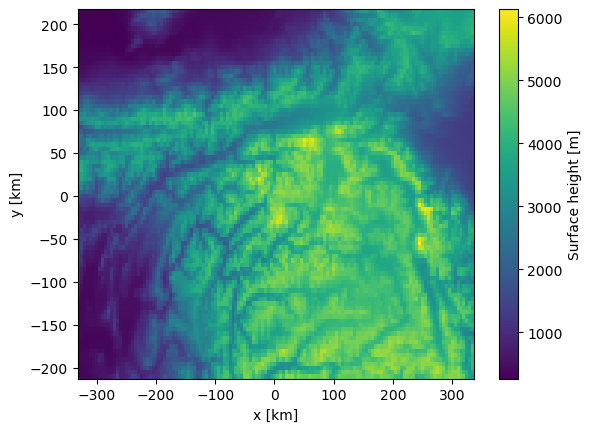

In [25]:
orog_mar.plot()

In [5]:
## Model MAR
model='MAR'
sourceDataGrid='/home/amoryc/'
fileName_gr='NST.2000.01.01.00.GRa_Fedchenko.nc_ICEmask'
#fileName_gr='NST.2000.01.01.00.GRa_Mera.nc_ICEmask'
ds_grM= xr.open_dataset(sourceDataGrid+fileName_gr)
dsSH=ds_grM['SH']

elev_flat = dsSH.values.flatten()
###Bin elevation (interval 250 m)
elev_bins = np.arange(0, np.max(elev_flat) + 250, 250)
elev_bin_labels = (elev_bins[:-1] + elev_bins[1:]) / 2

In [6]:
ds_TTZ_s2=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/MARout/'+domain+'/spin2/work/daily/'
                          +'TTZ_daymean_MARv3.14_ER5_spin2_'+domain+'_2016.nc')['TTZ'].isel(ZTQLEV=0)
# ##
ds_TTZ_30=xr.open_dataset(sourceData+'TTZ_daymean_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'30.nc')['TTZ'].isel(ZTQLEV=0)
ds_TTZ_31=xr.open_dataset(sourceData+'TTZ_daymean_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'31.nc')['TTZ'].isel(ZTQLEV=0)
ds_TTZ_32=xr.open_dataset(sourceData+'TTZ_daymean_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'32.nc')['TTZ'].isel(ZTQLEV=0)
ds_TTZ_33=xr.open_dataset(sourceData+'TTZ_daymean_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'33.nc')['TTZ'].isel(ZTQLEV=0)
ds_TTZ_34=xr.open_dataset(sourceData+'TTZ_daymean_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'34.nc')['TTZ'].isel(ZTQLEV=0)
ds_TTZ_35=xr.open_dataset(sourceData+'TTZ_daymean_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'35.nc')['TTZ'].isel(ZTQLEV=0)
ds_TTZ_36=xr.open_dataset(sourceData+'TTZ_daymean_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'36.nc')['TTZ'].isel(ZTQLEV=0)
ds_TTZ_37=xr.open_dataset(sourceData+'TTZ_daymean_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'37.nc')['TTZ'].isel(ZTQLEV=0)

In [7]:
##seasons

ds_TTZ_s2_per=ds_TTZ_s2[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')

ds_TTZ_30_per=ds_TTZ_30[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_TTZ_31_per=ds_TTZ_31[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_TTZ_32_per=ds_TTZ_32[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_TTZ_33_per=ds_TTZ_33[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_TTZ_34_per=ds_TTZ_34[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_TTZ_35_per=ds_TTZ_35[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_TTZ_36_per=ds_TTZ_36[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_TTZ_37_per=ds_TTZ_37[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')

In [ ]:
model3='era5-land'
ds_obs= xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/fainx/'+model3+'/era5_land_'+domain +'_t2m.nc')['t2m'] -273.15
ds_obs=ds_obs.rename({'valid_time':'time','longitude' :'lon','latitude' :'lat'})
ds_obs = ds_obs.sel(time=slice(iyr, fyr))

ds_obs_day = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/fainx/'+model3+'/2016/t2m.day_era5-land_2016.nc')['t2m'] -273.15
ds_obs_day_high = ds_obs_day.where(orog_mar > alti_thrs)
ds_obs_day_low = ds_obs_day.where(orog_mar < alti_thrs)

field_obs=dom.field_dom(ds_obs,domain_2)

field_obs_day=dom.field_dom(ds_obs_day,domain_2)
field_obs_day= field_obs_day.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})

field_obs_day_high=dom.field_dom(ds_obs_day_high,domain_2)
field_obs_day_high= field_obs_day_high.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})

field_obs_day_low=dom.field_dom(ds_obs_day_low,domain_2)
field_obs_day_low= field_obs_day_low.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})

ds_obs_per=field_obs.groupby('time.season').mean('time')

In [9]:
modelList=['ERA5-Land','spin2','30','31','32','33','34','35','36','37']

## MAM

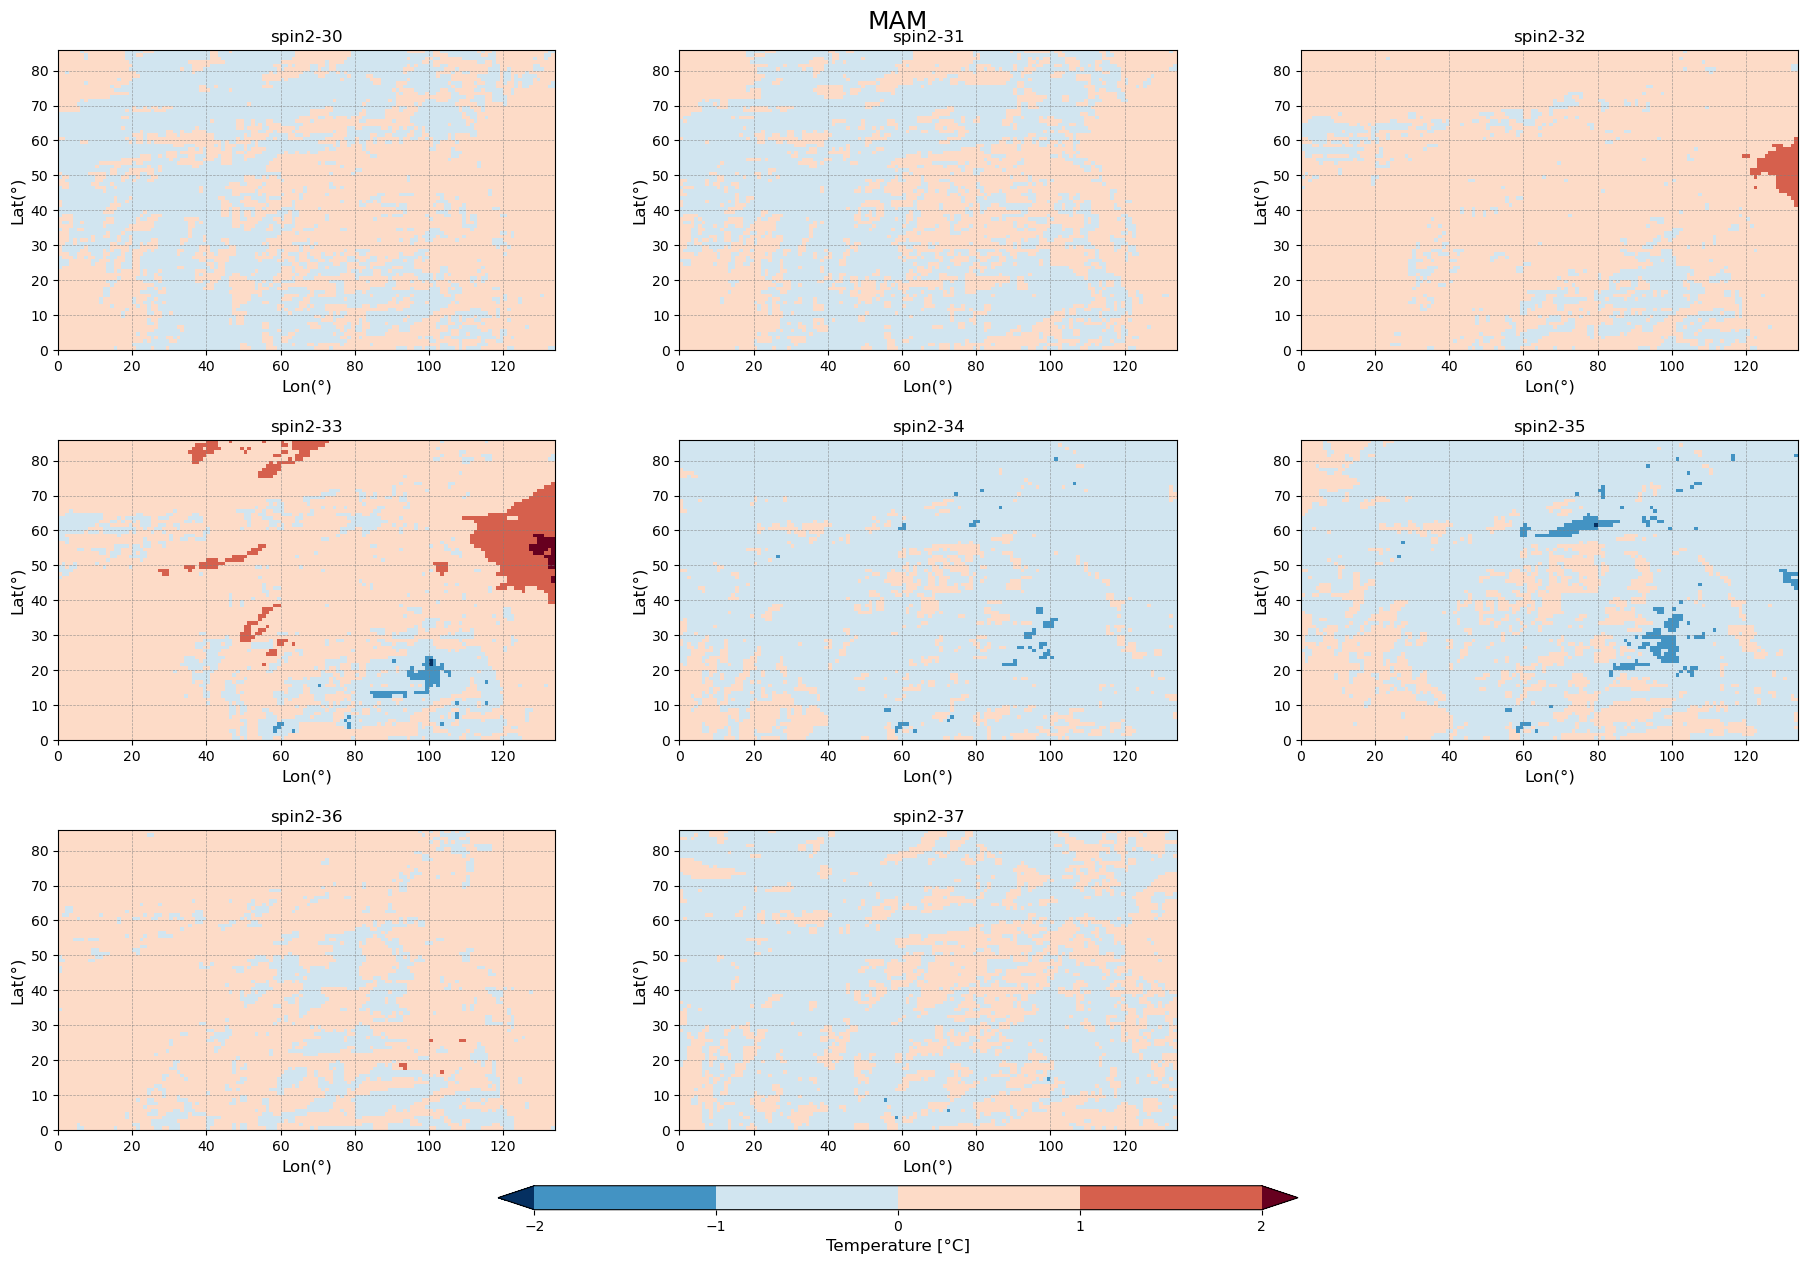

In [10]:
season='MAM'
# plotList=[ds_obs_per.sel(season=season),
#           ds_TTZ_s2_per.sel(season=season),
#           ds_TTZ_30_per.sel(season=season),
#           ds_TTZ_31_per.sel(season=season),
#           ds_TTZ_32_per.sel(season=season),
#           ds_TTZ_33_per.sel(season=season),
#           ds_TTZ_34_per.sel(season=season),
#           ds_TTZ_35_per.sel(season=season)]

plotList=[ds_TTZ_s2_per.sel(season=season)-ds_TTZ_30_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_31_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_32_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_33_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_34_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_35_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_36_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_37_per.sel(season=season)]


##
clevs=np.arange(-2,3,1);
cmap = plt.get_cmap("RdBu_r")
norm = plt.Normalize(vmin=clevs.min(), vmax=clevs.max())
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N, extend='both')
nrows=3
ncols=3

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,figsize=(20,20))
axs=axs.flatten()

i=0
# CS1= axs[i].pcolormesh(ds_obs_per.lon, ds_obs_per.lat, ds_obs_per.sel(season=season), cmap=cmap,  norm=norm)
# axs[i].grid(True,linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
# axs[i].set_xlabel('Lon(°)', fontsize=12)
# axs[i].set_ylabel('Lat(°)', fontsize=12)
# axs[i].set_title(modelList[i] )

                       
for i in np.arange(0,len(plotList),1):
    CS1 = axs[i].pcolormesh(plotList[i][:,:],
         cmap=cmap,
         norm=norm,
        )
    axs[i].grid(True,linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    axs[i].set_xlabel('Lon(°)', fontsize=12)
    axs[i].set_ylabel('Lat(°)', fontsize=12)
    axs[i].set_title('spin2-'+ modelList[i+2] )

title =season
fig.suptitle(title,y=0.9, fontsize = 18)

fig.subplots_adjust(bottom=0.34, top=0.84, left=0.10, right=0.90,wspace=0.2, hspace=0.2)
#axs[7].remove()   
axs[8].remove()   


# # --- Colorbar ---
cbar_ax = fig.add_axes([0.3, 0.30, 0.4, 0.012])  # [left, bottom, width, height]
cbar = fig.colorbar(CS1, cax=cbar_ax, orientation='horizontal',
                    boundaries=clevs, ticks=clevs, spacing='proportional')
cbar.set_label('Temperature [°C]', fontsize=12)

# --- Title and Layout ---
#fig.suptitle(title, y=0.92, fontsize=16)
fig.subplots_adjust(bottom=0.34, top=0.88, left=0.08, right=0.95, wspace=0.25, hspace=0.3)
#plt.savefig(outputDir+title+'.png',bbox_inches='tight')
plt.show()

## JJA

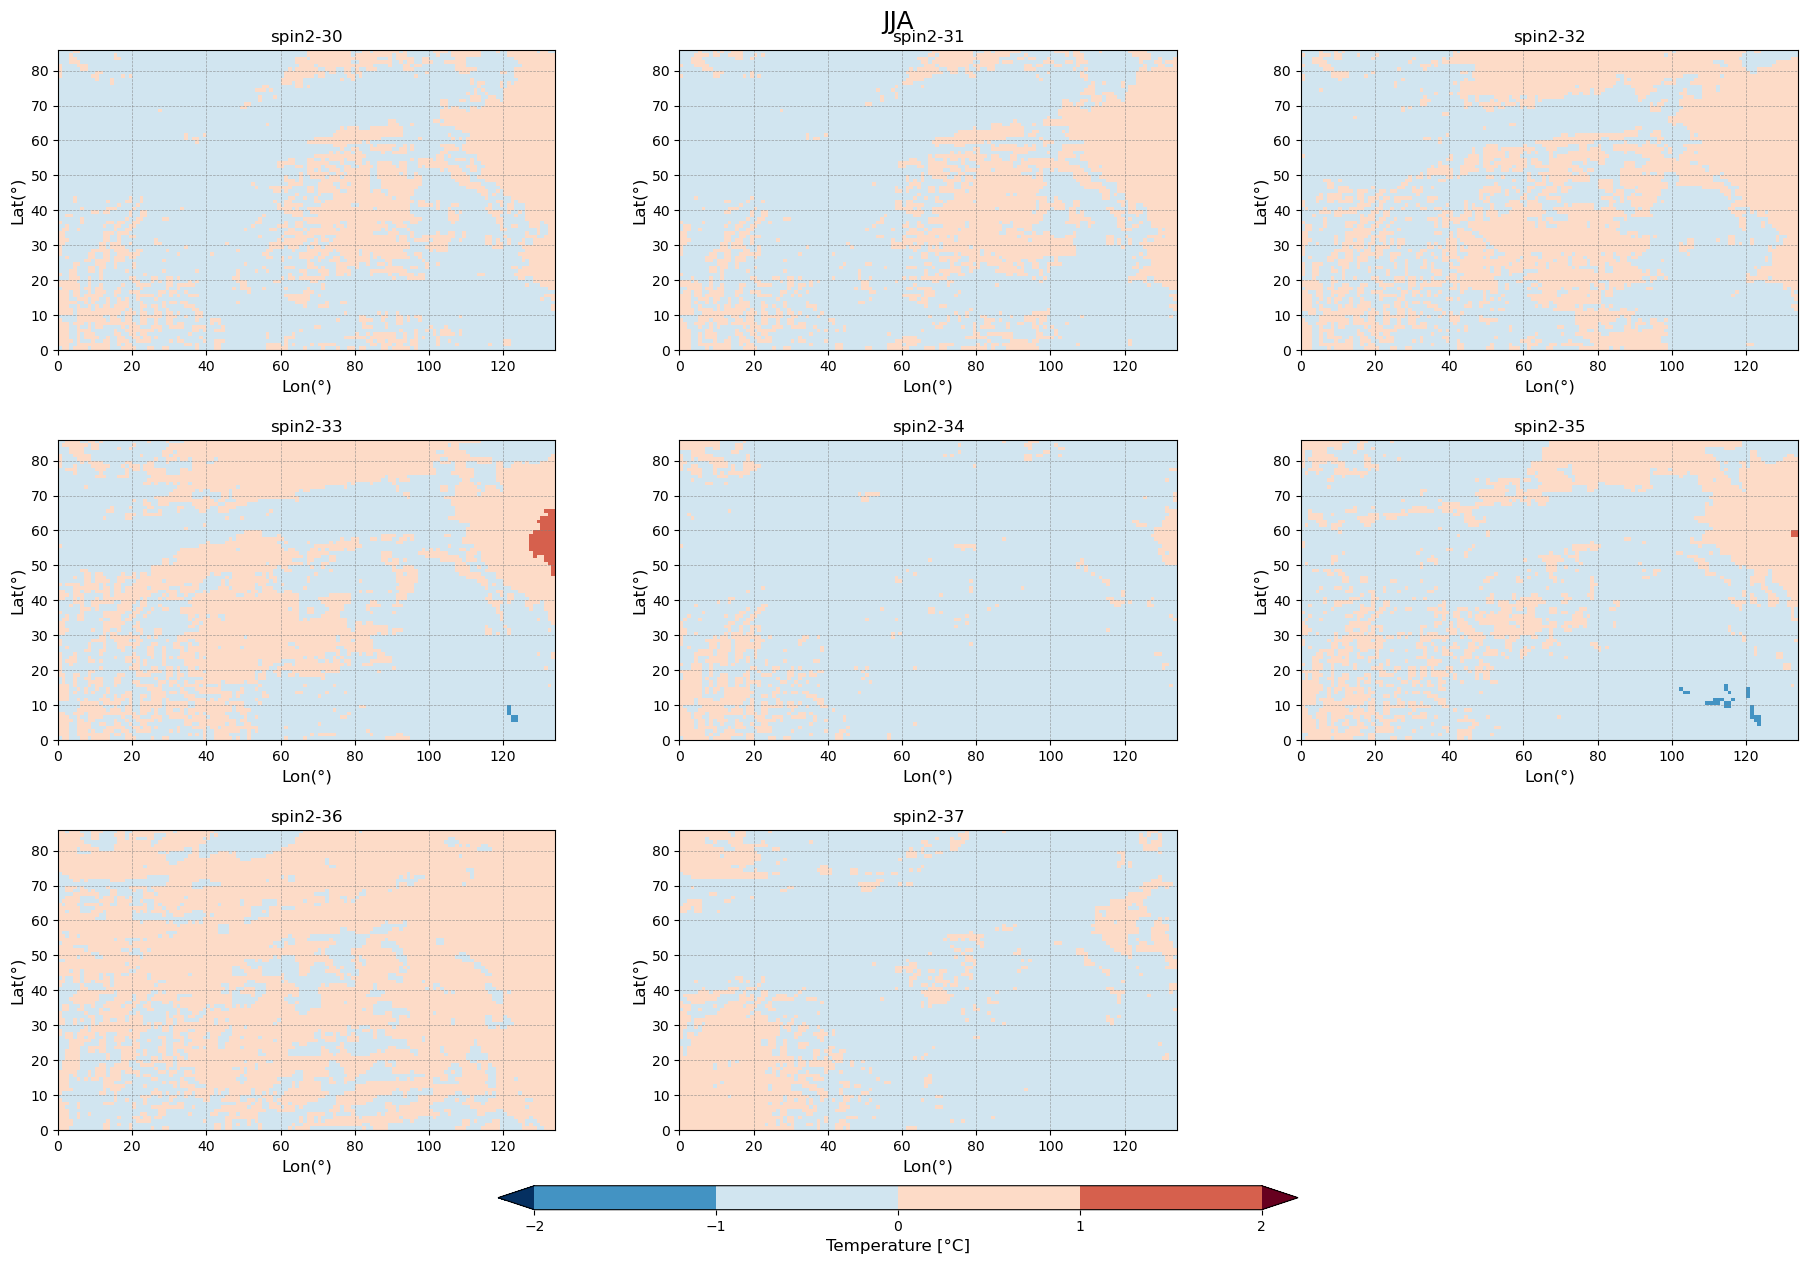

In [11]:
season='JJA'
# plotList=[ds_obs_per.sel(season=season),
#           ds_TTZ_s2_per.sel(season=season),
#           ds_TTZ_30_per.sel(season=season),
#           ds_TTZ_31_per.sel(season=season),
#           ds_TTZ_32_per.sel(season=season),
#           ds_TTZ_33_per.sel(season=season),
#           ds_TTZ_34_per.sel(season=season),
#           ds_TTZ_35_per.sel(season=season)]

plotList=[ds_TTZ_s2_per.sel(season=season)-ds_TTZ_30_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_31_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_32_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_33_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_34_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_35_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_36_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_37_per.sel(season=season)]

##
clevs=np.arange(-2,3,1);
cmap = plt.get_cmap("RdBu_r")
norm = plt.Normalize(vmin=clevs.min(), vmax=clevs.max())
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N, extend='both')
nrows=3
ncols=3

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,figsize=(20,20))
axs=axs.flatten()

i=0
# CS1= axs[i].pcolormesh(ds_obs_per.lon, ds_obs_per.lat, ds_obs_per.sel(season=season), cmap=cmap,  norm=norm)
# axs[i].grid(True,linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
# axs[i].set_xlabel('Lon(°)', fontsize=12)
# axs[i].set_ylabel('Lat(°)', fontsize=12)
# axs[i].set_title(modelList[i] )

                       
for i in np.arange(0,len(plotList),1):
    CS1 = axs[i].pcolormesh(plotList[i][:,:],
         cmap=cmap,
         norm=norm,
        )
    axs[i].grid(True,linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    axs[i].set_xlabel('Lon(°)', fontsize=12)
    axs[i].set_ylabel('Lat(°)', fontsize=12)
    axs[i].set_title('spin2-'+ modelList[i+2] )

title =season
fig.suptitle(title,y=0.9, fontsize = 18)

fig.subplots_adjust(bottom=0.34, top=0.84, left=0.10, right=0.90,wspace=0.2, hspace=0.2)
#axs[7].remove()   
axs[8].remove()   


# # --- Colorbar ---
cbar_ax = fig.add_axes([0.3, 0.30, 0.4, 0.012])  # [left, bottom, width, height]
cbar = fig.colorbar(CS1, cax=cbar_ax, orientation='horizontal',
                    boundaries=clevs, ticks=clevs, spacing='proportional')
cbar.set_label('Temperature [°C]', fontsize=12)

# --- Title and Layout ---
#fig.suptitle(title, y=0.92, fontsize=16)
fig.subplots_adjust(bottom=0.34, top=0.88, left=0.08, right=0.95, wspace=0.25, hspace=0.3)
#plt.savefig(outputDir+title+'.png',bbox_inches='tight')
plt.show()

## SON

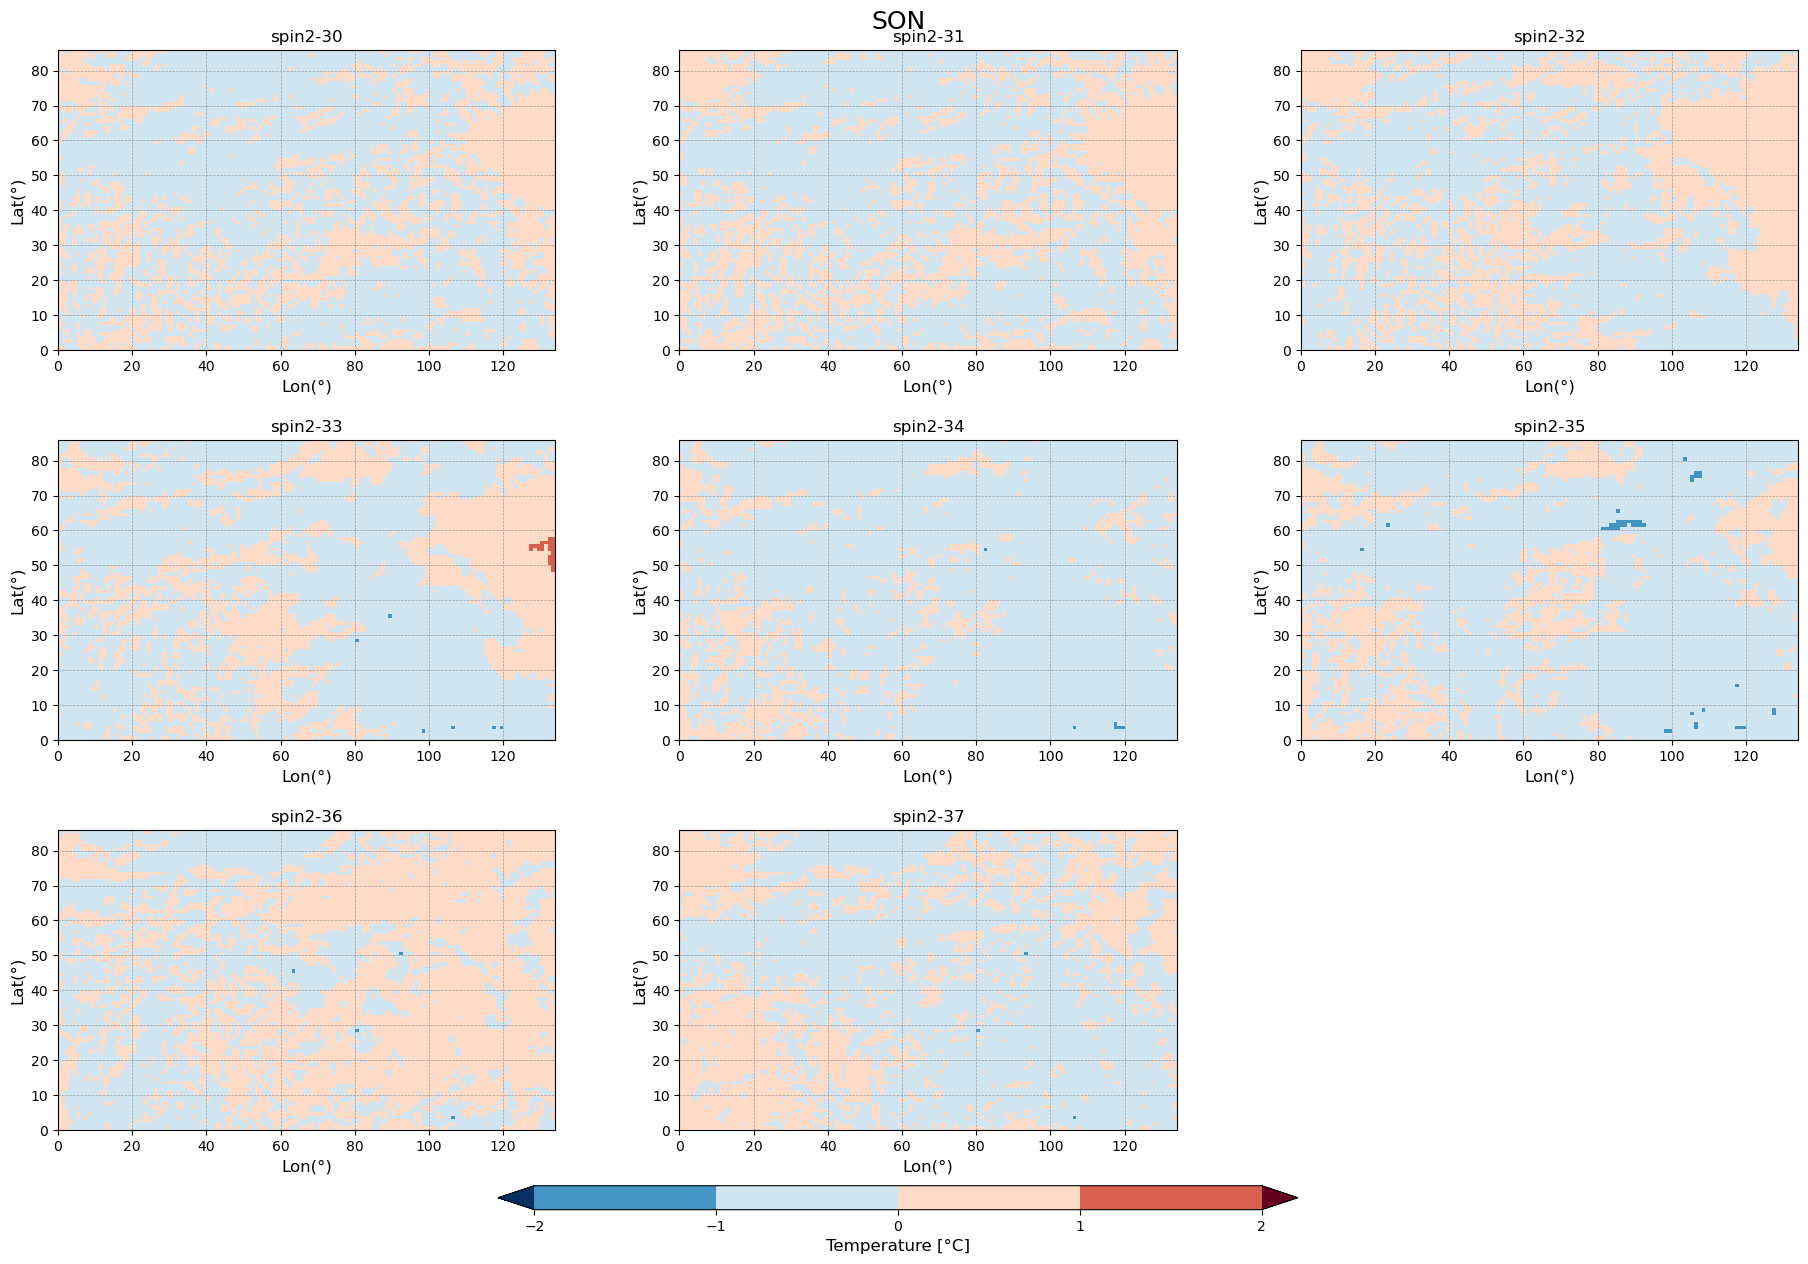

In [12]:
season='SON'
# plotList=[ds_obs_per.sel(season=season),
#           ds_TTZ_s2_per.sel(season=season),
#           ds_TTZ_30_per.sel(season=season),
#           ds_TTZ_31_per.sel(season=season),
#           ds_TTZ_32_per.sel(season=season),
#           ds_TTZ_33_per.sel(season=season),
#           ds_TTZ_34_per.sel(season=season),
#           ds_TTZ_35_per.sel(season=season)]

plotList=[ds_TTZ_s2_per.sel(season=season)-ds_TTZ_30_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_31_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_32_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_33_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_34_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_35_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_36_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_37_per.sel(season=season)]

##
clevs=np.arange(-2,3,1);
cmap = plt.get_cmap("RdBu_r")
norm = plt.Normalize(vmin=clevs.min(), vmax=clevs.max())
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N, extend='both')
nrows=3
ncols=3

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,figsize=(20,20))
axs=axs.flatten()

i=0
# CS1= axs[i].pcolormesh(ds_obs_per.lon, ds_obs_per.lat, ds_obs_per.sel(season=season), cmap=cmap,  norm=norm)
# axs[i].grid(True,linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
# axs[i].set_xlabel('Lon(°)', fontsize=12)
# axs[i].set_ylabel('Lat(°)', fontsize=12)
# axs[i].set_title(modelList[i] )
                       
for i in np.arange(0,len(plotList),1):
    CS1 = axs[i].pcolormesh(plotList[i][:,:],
         cmap=cmap,
         norm=norm,
        )
    axs[i].grid(True,linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    axs[i].set_xlabel('Lon(°)', fontsize=12)
    axs[i].set_ylabel('Lat(°)', fontsize=12)
    axs[i].set_title('spin2-'+ modelList[i+2] )

title =season
fig.suptitle(title,y=0.9, fontsize = 18)

fig.subplots_adjust(bottom=0.34, top=0.84, left=0.10, right=0.90,wspace=0.2, hspace=0.2)
#axs[7].remove()   
axs[8].remove()   


# # --- Colorbar ---
cbar_ax = fig.add_axes([0.3, 0.30, 0.4, 0.012])  # [left, bottom, width, height]
cbar = fig.colorbar(CS1, cax=cbar_ax, orientation='horizontal',
                    boundaries=clevs, ticks=clevs, spacing='proportional')
cbar.set_label('Temperature [°C]', fontsize=12)

# --- Title and Layout ---
#fig.suptitle(title, y=0.92, fontsize=16)
fig.subplots_adjust(bottom=0.34, top=0.88, left=0.08, right=0.95, wspace=0.25, hspace=0.3)
#plt.savefig(outputDir+title+'.png',bbox_inches='tight')
plt.show()

# DJF

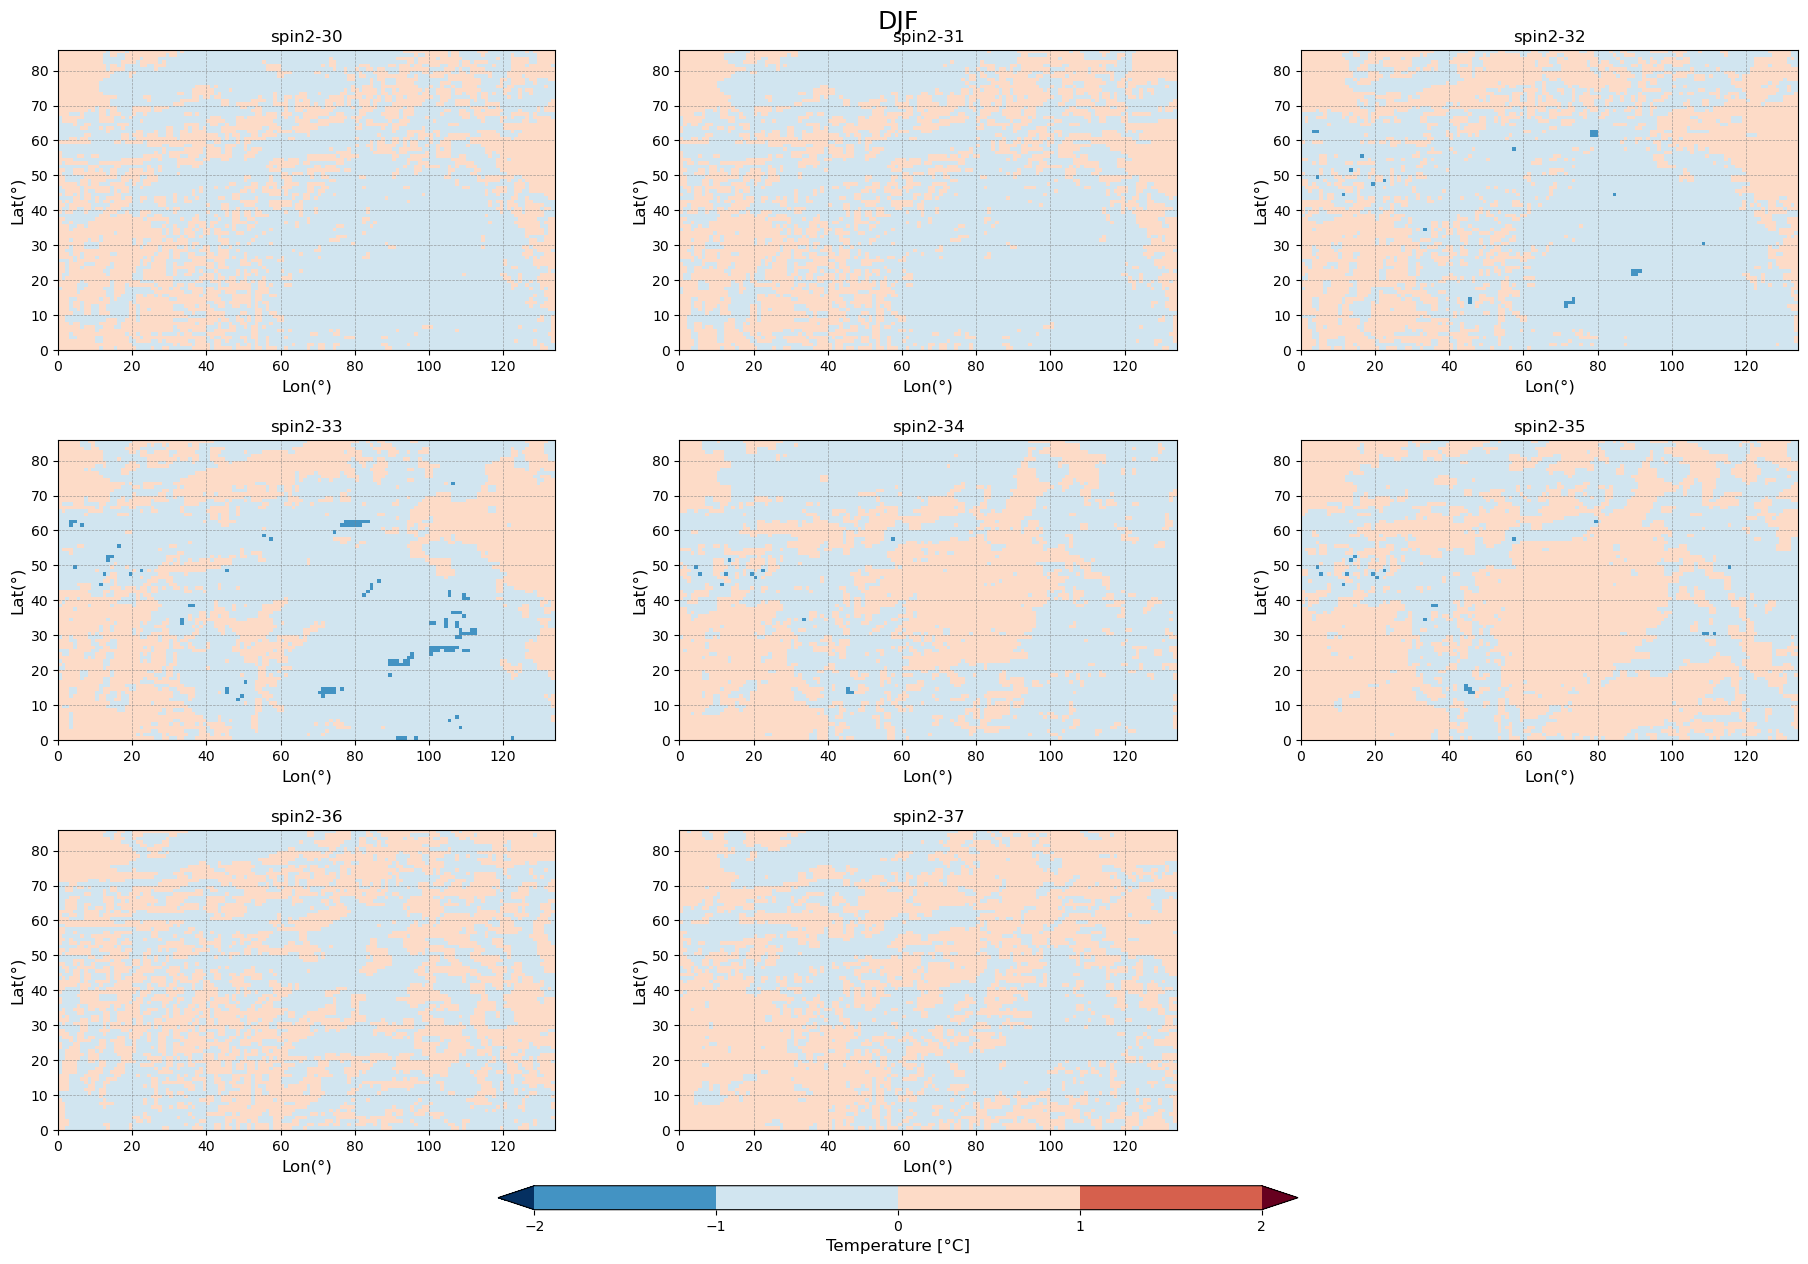

In [13]:
season='DJF'
# plotList=[ds_obs_per.sel(season=season),
#           ds_TTZ_s2_per.sel(season=season),
#           ds_TTZ_30_per.sel(season=season),
#           ds_TTZ_31_per.sel(season=season),
#           ds_TTZ_32_per.sel(season=season),
#           ds_TTZ_33_per.sel(season=season),
#           ds_TTZ_34_per.sel(season=season),
#           ds_TTZ_35_per.sel(season=season)]

plotList=[ds_TTZ_s2_per.sel(season=season)-ds_TTZ_30_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_31_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_32_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_33_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_34_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_35_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_36_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_37_per.sel(season=season)]
##
clevs=np.arange(-2,3,1);
cmap = plt.get_cmap("RdBu_r")
norm = plt.Normalize(vmin=clevs.min(), vmax=clevs.max())
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N, extend='both')
nrows=3
ncols=3

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,figsize=(20,20))
axs=axs.flatten()

i=0
# CS1= axs[i].pcolormesh(ds_obs_per.lon, ds_obs_per.lat, ds_obs_per.sel(season=season), cmap=cmap,  norm=norm)
# axs[i].grid(True,linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
# axs[i].set_xlabel('Lon(°)', fontsize=12)
# axs[i].set_ylabel('Lat(°)', fontsize=12)
# axs[i].set_title(modelList[i] )

                       
for i in np.arange(0,len(plotList),1):
    CS1 = axs[i].pcolormesh(plotList[i][:,:],
         cmap=cmap,
         norm=norm,
        )
    axs[i].grid(True,linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    axs[i].set_xlabel('Lon(°)', fontsize=12)
    axs[i].set_ylabel('Lat(°)', fontsize=12)
    axs[i].set_title('spin2-'+ modelList[i+2] )

title =season
fig.suptitle(title,y=0.9, fontsize = 18)

fig.subplots_adjust(bottom=0.34, top=0.84, left=0.10, right=0.90,wspace=0.2, hspace=0.2)
#axs[7].remove()   
axs[8].remove()   


# # --- Colorbar ---
cbar_ax = fig.add_axes([0.3, 0.30, 0.4, 0.012])  # [left, bottom, width, height]
cbar = fig.colorbar(CS1, cax=cbar_ax, orientation='horizontal',
                    boundaries=clevs, ticks=clevs, spacing='proportional')
cbar.set_label('Temperature [°C]', fontsize=12)

# --- Title and Layout ---
#fig.suptitle(title, y=0.92, fontsize=16)
fig.subplots_adjust(bottom=0.34, top=0.88, left=0.08, right=0.95, wspace=0.25, hspace=0.3)
#plt.savefig(outputDir+title+'.png',bbox_inches='tight')
plt.show()

## Timeseries

In [73]:
tt=field_obs.mean('lon')
ts_obs=tt.mean('lat')

tt_day=field_obs_day.mean('lon')
ts_obs_day=tt_day.mean('lat')

In [53]:
ts_TTZ_s2=ds_TTZ_s2[nx:-nx,ny:-ny].mean('X').mean('Y')
ts_TTZ_30=ds_TTZ_30[nx:-nx,ny:-ny].mean('X').mean('Y')
ts_TTZ_31=ds_TTZ_31[nx:-nx,ny:-ny].mean('X').mean('Y')
ts_TTZ_32=ds_TTZ_32[nx:-nx,ny:-ny].mean('X').mean('Y')
ts_TTZ_33=ds_TTZ_33[nx:-nx,ny:-ny].mean('X').mean('Y')
ts_TTZ_34=ds_TTZ_34[nx:-nx,ny:-ny].mean('X').mean('Y')
ts_TTZ_35=ds_TTZ_35[nx:-nx,ny:-ny].mean('X').mean('Y')
ts_TTZ_36=ds_TTZ_36[nx:-nx,ny:-ny].mean('X').mean('Y')
ts_TTZ_37=ds_TTZ_37[nx:-nx,ny:-ny].mean('X').mean('Y')

In [54]:
colorList=['red','orange','blue','brown','fuchsia','purple','grey','pink']

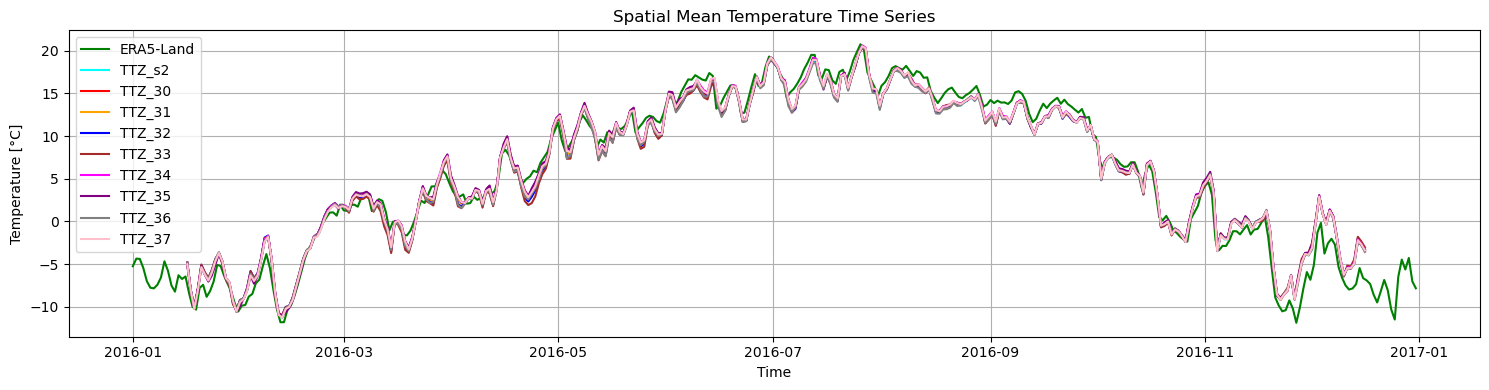

In [75]:
fig=plt.figure(figsize=(15, 4))

# plt.plot(ts_obs.time,ts_obs, '-o', label='ERA5-Land',color='green')
plt.plot(ts_obs_day.time,ts_obs_day, label='ERA5-Land',color='green')

plt.plot(ts_TTZ_30.TIME,ts_TTZ_s2,label='TTZ_s2',color='cyan')
plt.plot(ts_TTZ_30.TIME,ts_TTZ_30,label='TTZ_30',color=colorList[0])
plt.plot(ts_TTZ_30.TIME,ts_TTZ_31,label='TTZ_31',color=colorList[1])
plt.plot(ts_TTZ_30.TIME,ts_TTZ_32,label='TTZ_32',color=colorList[2])
plt.plot(ts_TTZ_30.TIME,ts_TTZ_33,label='TTZ_33',color=colorList[3])
plt.plot(ts_TTZ_30.TIME,ts_TTZ_34,label='TTZ_34',color=colorList[4])
plt.plot(ts_TTZ_30.TIME,ts_TTZ_35,label='TTZ_35',color=colorList[5])
plt.plot(ts_TTZ_30.TIME,ts_TTZ_36,label='TTZ_36',color=colorList[6])
plt.plot(ts_TTZ_30.TIME,ts_TTZ_37,label='TTZ_37',color=colorList[7])

# Plot formatting
plt.xlabel('Time')
plt.ylabel('Temperature [°C]')  # Update with correct units
plt.title('Spatial Mean Temperature Time Series')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
# Selection des données montagne vs plaine
alti_thrs = 2500

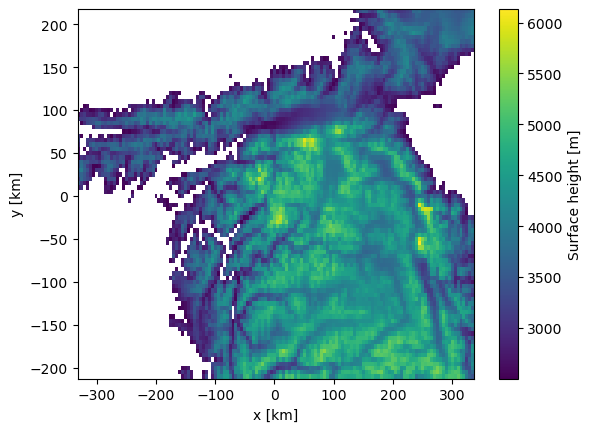

In [41]:
orog_mar.where(orog_mar > alti_thrs).plot()

In [99]:
ts_obs_day_high = ts_obs_day.where(orog_mar > alti_thrs)
ts_obs_day_high=ts_obs_day_high.mean('X').mean('Y')

ts_TTZ_s2_high=ds_TTZ_s2.where(orog_mar > alti_thrs).mean('X').mean('Y')
ts_TTZ_30_high=ds_TTZ_30.where(orog_mar > alti_thrs).mean('X').mean('Y')
ts_TTZ_31_high=ds_TTZ_31.where(orog_mar > alti_thrs).mean('X').mean('Y')
ts_TTZ_32_high=ds_TTZ_32.where(orog_mar > alti_thrs).mean('X').mean('Y')
ts_TTZ_33_high=ds_TTZ_33.where(orog_mar > alti_thrs).mean('X').mean('Y')
ts_TTZ_34_high=ds_TTZ_34.where(orog_mar > alti_thrs).mean('X').mean('Y')
ts_TTZ_35_high=ds_TTZ_35.where(orog_mar > alti_thrs).mean('X').mean('Y')
ts_TTZ_36_high=ds_TTZ_36.where(orog_mar > alti_thrs).mean('X').mean('Y')
ts_TTZ_37_high=ds_TTZ_37.where(orog_mar > alti_thrs).mean('X').mean('Y')

In [94]:
ts_obs_day_low = ts_obs_day.where(orog_mar < alti_thrs)

ts_TTZ_s2_low=ds_TTZ_s2.where(orog_mar < alti_thrs).mean('X').mean('Y')
ts_TTZ_30_low=ds_TTZ_30.where(orog_mar < alti_thrs).mean('X').mean('Y')
ts_TTZ_31_low=ds_TTZ_31.where(orog_mar < alti_thrs).mean('X').mean('Y')
ts_TTZ_32_low=ds_TTZ_32.where(orog_mar < alti_thrs).mean('X').mean('Y')
ts_TTZ_33_low=ds_TTZ_33.where(orog_mar < alti_thrs).mean('X').mean('Y')
ts_TTZ_34_low=ds_TTZ_34.where(orog_mar < alti_thrs).mean('X').mean('Y')
ts_TTZ_35_low=ds_TTZ_35.where(orog_mar < alti_thrs).mean('X').mean('Y')
ts_TTZ_36_low=ds_TTZ_36.where(orog_mar < alti_thrs).mean('X').mean('Y')
ts_TTZ_37_low=ds_TTZ_37.where(orog_mar < alti_thrs).mean('X').mean('Y')

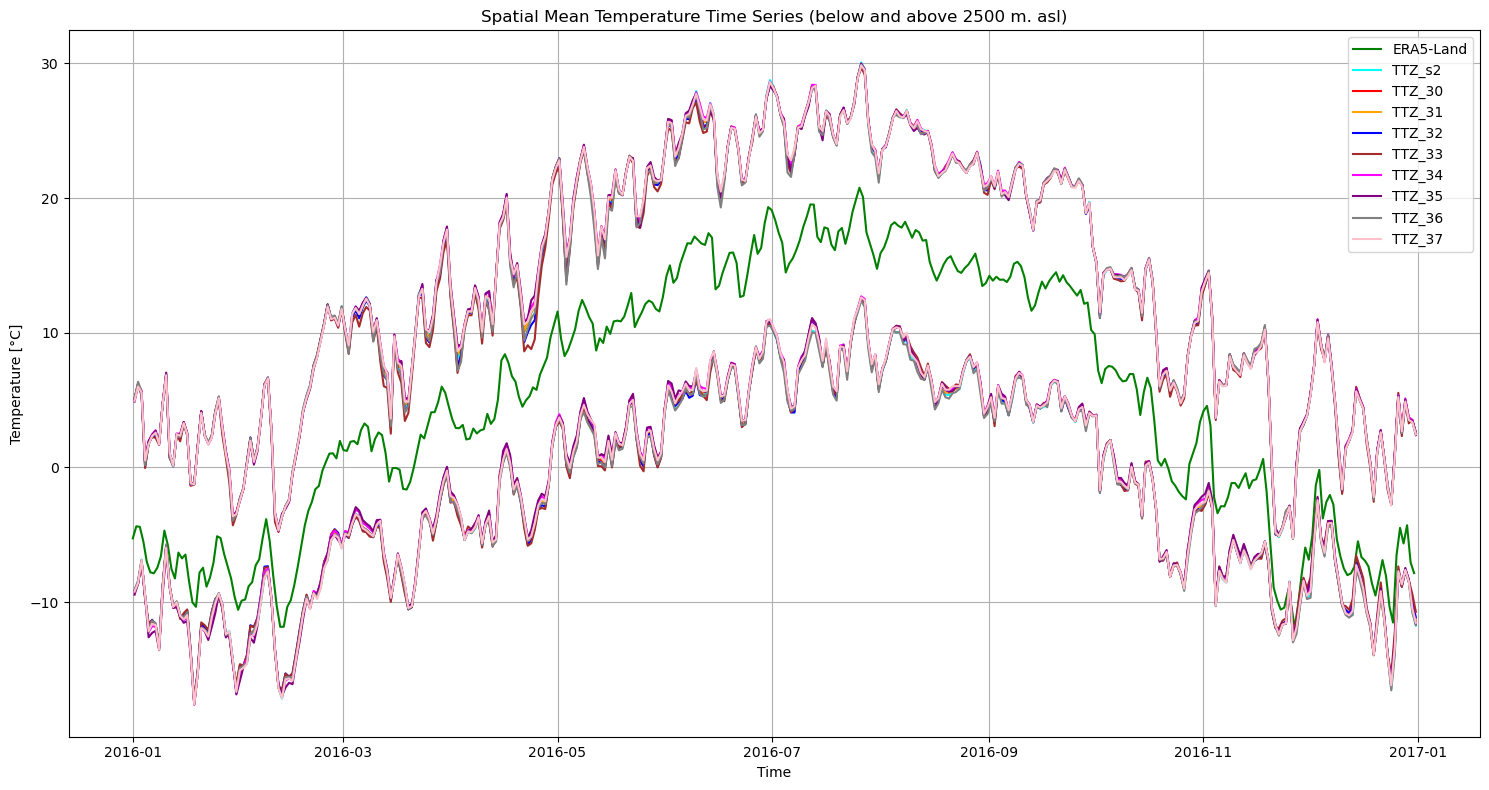

In [100]:
fig=plt.figure(figsize=(15, 8))

# plt.plot(ts_obs.time,ts_obs, '-o', label='ERA5-Land',color='green')
plt.plot(ts_obs_day_high.time,ts_obs_day_high, label='ERA5-Land',color='green')
plt.plot(ts_TTZ_30_high.TIME,ts_TTZ_s2_high,label='TTZ_s2',color='cyan')
plt.plot(ts_TTZ_30_high.TIME,ts_TTZ_30_high,label='TTZ_30',color=colorList[0])
plt.plot(ts_TTZ_30_high.TIME,ts_TTZ_31_high,label='TTZ_31',color=colorList[1])
plt.plot(ts_TTZ_30_high.TIME,ts_TTZ_32_high,label='TTZ_32',color=colorList[2])
plt.plot(ts_TTZ_30_high.TIME,ts_TTZ_33_high,label='TTZ_33',color=colorList[3])
plt.plot(ts_TTZ_30_high.TIME,ts_TTZ_34_high,label='TTZ_34',color=colorList[4])
plt.plot(ts_TTZ_30_high.TIME,ts_TTZ_35_high,label='TTZ_35',color=colorList[5])
plt.plot(ts_TTZ_30_high.TIME,ts_TTZ_36_high,label='TTZ_36',color=colorList[6])
plt.plot(ts_TTZ_30_high.TIME,ts_TTZ_37_high,label='TTZ_37',color=colorList[7])


# plt.plot(ts_obs.time,ts_obs, '-o', label='ERA5-Land',color='green')
# plt.plot(ts_obs_day_low.time,ts_obs_day_low, label='ERA5-Land',color='green')
plt.plot(ts_TTZ_30_low.TIME,ts_TTZ_s2_low,color='cyan')
plt.plot(ts_TTZ_30_low.TIME,ts_TTZ_30_low,color=colorList[0])
plt.plot(ts_TTZ_30_low.TIME,ts_TTZ_31_low,color=colorList[1])
plt.plot(ts_TTZ_30_low.TIME,ts_TTZ_32_low,color=colorList[2])
plt.plot(ts_TTZ_30_low.TIME,ts_TTZ_33_low,color=colorList[3])
plt.plot(ts_TTZ_30_low.TIME,ts_TTZ_34_low,color=colorList[4])
plt.plot(ts_TTZ_30_low.TIME,ts_TTZ_35_low,color=colorList[5])
plt.plot(ts_TTZ_30_low.TIME,ts_TTZ_36_low,color=colorList[6])
plt.plot(ts_TTZ_30_low.TIME,ts_TTZ_37_low,color=colorList[7])

# Plot formatting
plt.xlabel('Time')
plt.ylabel('Temperature [°C]')  # Update with correct units
plt.title('Spatial Mean Temperature Time Series (below and above '+str(alti_thrs)+' m. asl)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
dsF = dsF[:,k:-k,k:-k]

#### Need to process this plot by altitudinal ranges and with daily resolution ERA5-Land dataset

## Altitudinal Profiles

In [18]:
dsList=[ds_TTZ_s2,ds_TTZ_30,ds_TTZ_31,ds_TTZ_32,ds_TTZ_33,ds_TTZ_34,ds_TTZ_35,ds_TTZ_36,ds_TTZ_37]

In [19]:
mean_tmp_by_elev_List=[]

for elem in dsList:
    tmp_flat = elem.mean('TIME').values.flatten()
    df = pd.DataFrame({'elevation': elev_flat, 'tmp': tmp_flat})
    df['elev_bin'] = pd.cut(df['elevation'], bins=elev_bins, labels=elev_bin_labels)
    mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
    mean_tmp_by_elev_List.append(mean_tmp_by_elev)    

/tmp/ipykernel_730317/1135626708.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
/tmp/ipykernel_730317/1135626708.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
/tmp/ipykernel_730317/1135626708.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
/

In [20]:
elev_bin_labels_R=np.array([0, 125.,  375.,  625.,  875., 1125., 1375., 1625., 1875., 2125.,
       2375., 2625., 2875., 3125., 3375., 3625., 3875., 4125., 4375.,
       4625., 4875., 5125., 5375., 5625., 5875., 6125., 6375., 6625.,
       6875., 7125.])

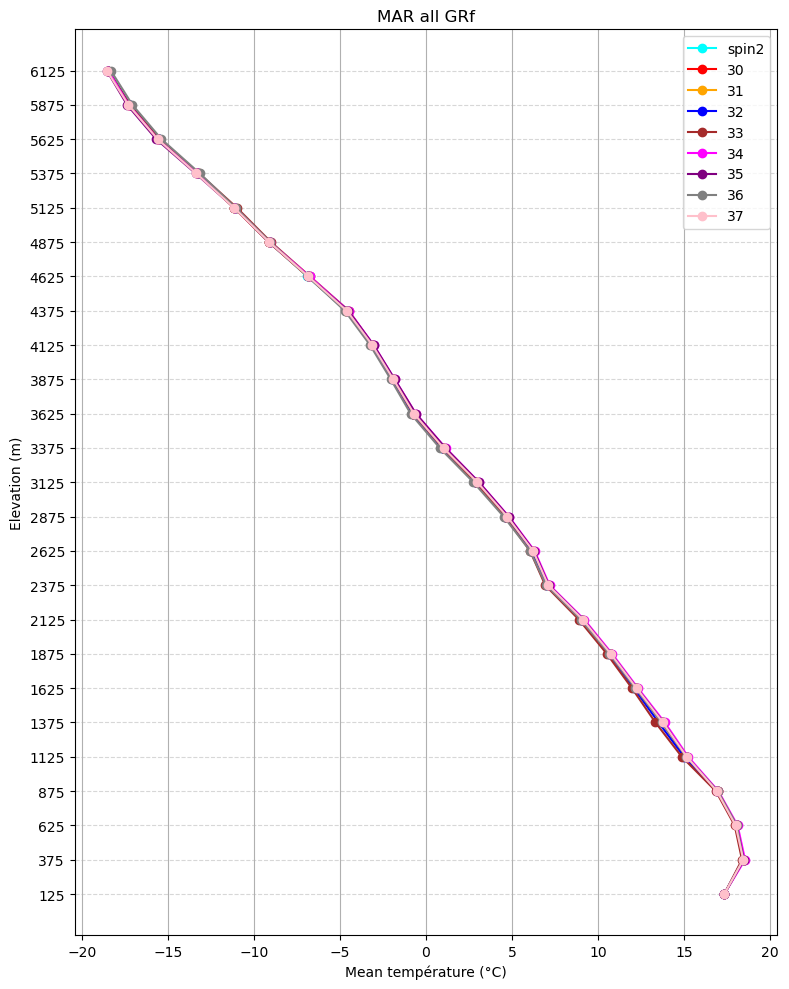

In [21]:
fig=plt.figure(figsize=(8, 10))

plt.plot(mean_tmp_by_elev_List[0].values,elev_bin_labels, marker='o',color='cyan',
         label=modelList[1+0])

for i in np.arange(1,len(dsList[1:])+1,1):
                   
    plt.plot(mean_tmp_by_elev_List[i].values,elev_bin_labels, marker='o',color=colorList[i-1],
         label=modelList[1+i])
             
plt.yticks(ticks=elev_bin_labels)
plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)

plt.ylabel('Elevation (m)')
plt.xlabel('Mean température (°C)')
plt.title('MAR all ' +domain)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()